<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 7
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consigna

Usando el archivo ecg.mat que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptadas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

**Ayuda:** Los detalles de cómo acceder a ecg.mat los pueden encontrar en lectura_sigs.py

## *Archivo ECG.mat*

*(variables)*

- ***ecg_lead***: Registro de ECG muestreado a *fs* = 1 kHz durante una prueba de esfuerzo
- ***qrs_pattern1***: Complejo de ondas QRS normal
- ***heartbeat_pattern1***: Latido normal
- ***heartbeat_pattern2***: Latido de origen ventricular
- ***qrs_detections***: vector con las localizaciones (en # de muestras) donde ocurren los latidos


**Se pide:**

**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** Utilice los resultados del ancho de banda estimado del ECG **en la Tarea Semanal 5**. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.

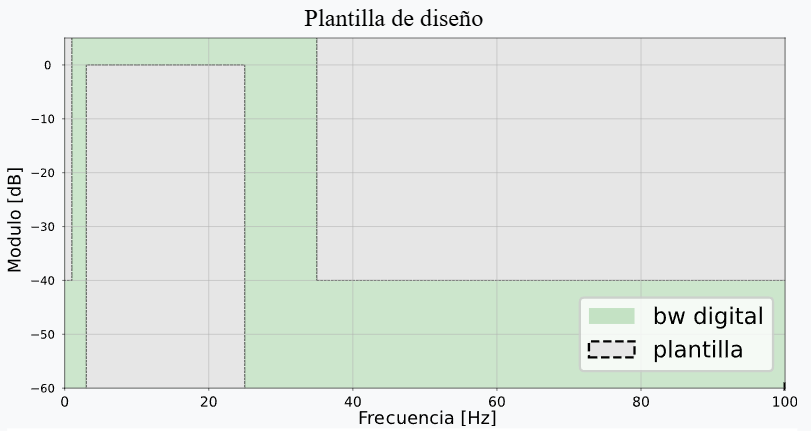
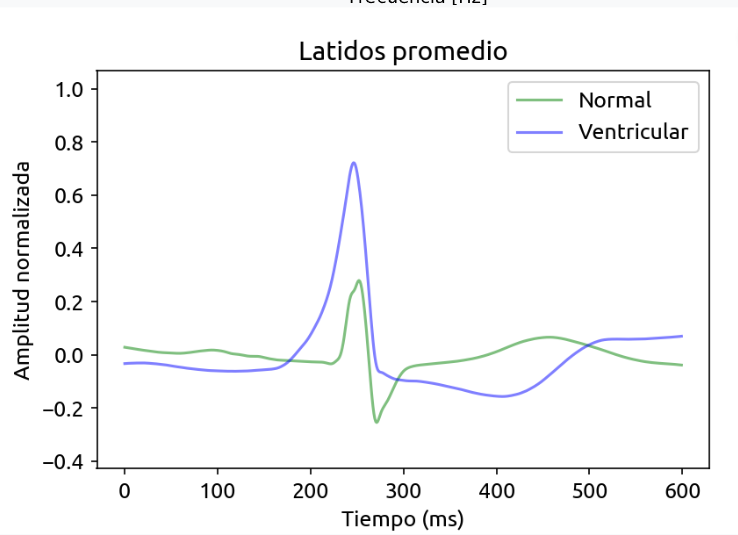
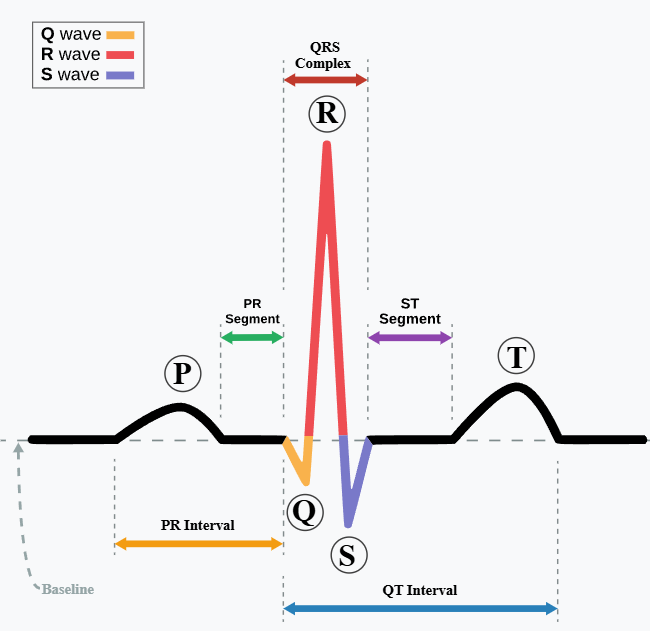


In [ ]:
#############
# Plantilla #
#############
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = ?? # Hz
wp1 = ?? # Hz
wp2 = ?? # Hz
ws2 = ?? # Hz
 
# plantilla normalizada a Nyquist en dB
frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
 
# convertimos a veces para las funciones de diseño
gains = 10**(gains/20)

**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe **al menos** dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** Para los filtros IIR adopte las aproximaciones de módulo de [máxima planicidad, Chebyshev y Cauer](). Para los FIR, utilice las metodologías de [ventanas, cuadrados mínimos]() y [Parks-Mc Clellan-Remez](). Todos implementados en [SciPy.Signal]()

**d)** Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.

**Ayuda:** Utilice el siguiente código como referencia para analizar los puntos 1 y 2). **También puede incluir otras regiones que considere de interés.**

In [ ]:
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(1)
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(2)
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

**Bonus:**

- 💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

# Plantilla de diseño 


Se comienza por importar las librerias a utilizar y cargar el archivo bajo el cual se hara el desarrollo del trabajo.

In [2]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio

sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']
N = len(ecg_one_lead)

hb_1 = mat_struct['heartbeat_pattern1']
hb_2 = mat_struct['heartbeat_pattern2']

ecg_one_lead = mat_struct['ecg_lead'].flatten()

# Si se desea visualizar los datos ... 

# plt.figure()
# plt.plot(ecg_one_lead[5000:12000]) # Esta limitado porque son demasiados datos
# plt.grid(True, linestyle='--', alpha=0.5)

# plt.figure()
# plt.plot(hb_1)

# plt.figure()
# plt.plot(hb_2)

A continuacion, se define la plantilla que será utilizada como guia para la creacion de los filtros a utilizar. 
Como bien se menciona en la consigna del trabajo, la idea principal es mitigar las diversas fuentes de contaminación que afectan la correcta lectura de los datos.

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

Por lo tanto se trabajara con filtros del estilo pasabanda. Para ello se fijan los parametros ws1 = 0.1 Hz, wp1 = 0.5 Hz, wp2 = 35 Hz y ws2 = 45 Hz, los cuales responden directamente a los requerimientos clínicos y de procesamiento de señales para registros electrocardiográficos.

El movimiento respiratorio del paciente y los cambios de impedancia en la interfaz electrodo-piel introducen un ruido de muy baja frecuencia (típicamente entre 0.05 Hz y 1 Hz). Al fijar el inicio de la banda de paso en wp1 = 0.5 Hz y asegurar una fuerte atenuación (mínimo de 40 dB) en ws1 = 0.1 Hz, se mitiga de forma drástica esta deriva analógica, logrando un nivel isoeléctrico nulo y estable.

La mayor parte de la energía del complejo QRS (que representa la despolarización ventricular y define las ondas de mayor pendiente en el ECG) se concentra por debajo de los 30 Hz - 40 Hz. Al fijar wp2 = 35 Hz, se garantiza que los picos de las ondas R no sufran una atenuación excesiva (atenuación menor a 3 dB), manteniendo la suavidad de los trazos sin distorsionar la amplitud real de los latidos.

Al asegurar que la banda de rechazo comience de forma estricta en los 45 Hz con una atenuación de 40 dB, el filtro degrada masivamente cualquier acople de la red eléctrica de 50 Hz (frecuencia estándar industrial), eliminando este zumbido clásico sin necesidad de añadir un filtro notch adicional.

In [3]:
def limites_plantilla():
    ws1 = 0.1
    wp1 = 0.5
    wp2 = 35
    ws2 = 45

    f_min, f_max = 0, 100
    gain_min, gain_max = -60, 5

    # Banda de rechazo inferior (0 a ws1): Prohibido arriba de -40 dB
    plt.fill_between([0, ws1], -40, gain_max, color='red', alpha=0.3, label='Zona Prohibida')

    # Banda de paso (wp1 a wp2): 
    # Prohibido abajo de -3 dB (tolerancia de rizado) y arriba de 0 dB
    plt.fill_between([wp1, wp2], gain_min, -3, color='red', alpha=0.3)
    plt.fill_between([wp1, wp2], 0, gain_max, color='red', alpha=0.3)

    # Banda de rechazo superior (ws2 a 100 Hz): Prohibido arriba de -40 dB
    plt.fill_between([ws2, f_max], -40, gain_max, color='red', alpha=0.3)

    frecuencias = [ws1, wp1, wp2, ws2]
    etiquetas = [f'ws1 = {ws1}', f'wp1 = {wp1}', f'wp2 = {wp2}', f'ws2 = {ws2}']
    colores = ['darkred', 'darkgreen', 'darkgreen', 'darkred']

    plt.axhline(y=-40, color='gray', linestyle='-', alpha=0.5)
    plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

    plt.xlim(f_min, f_max)
    plt.ylim(gain_min, gain_max)
    
    return

Podemos visualizar la plantilla en el siguiente bloque.

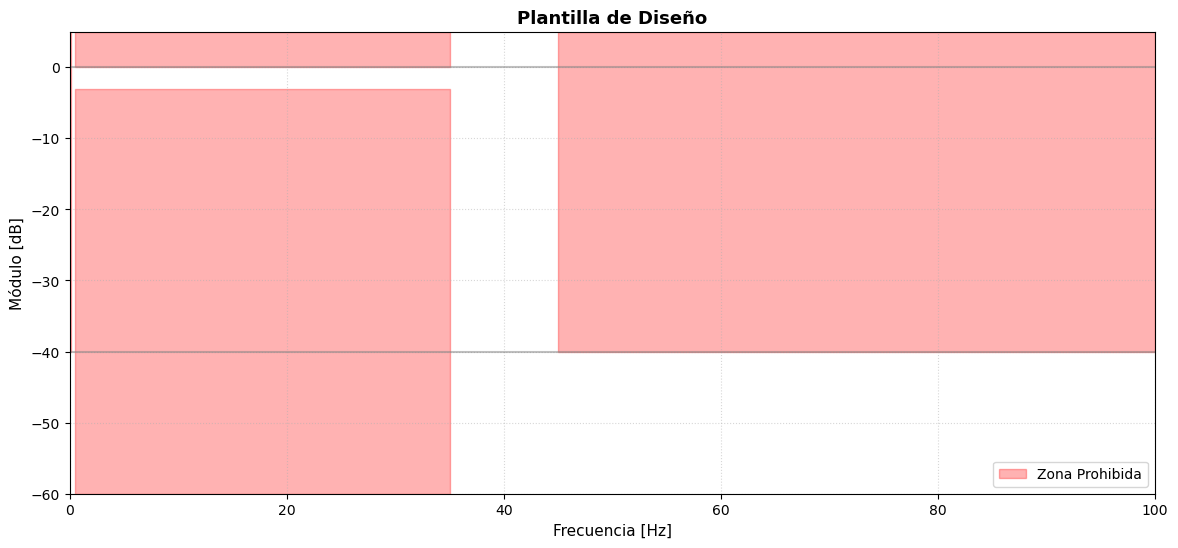

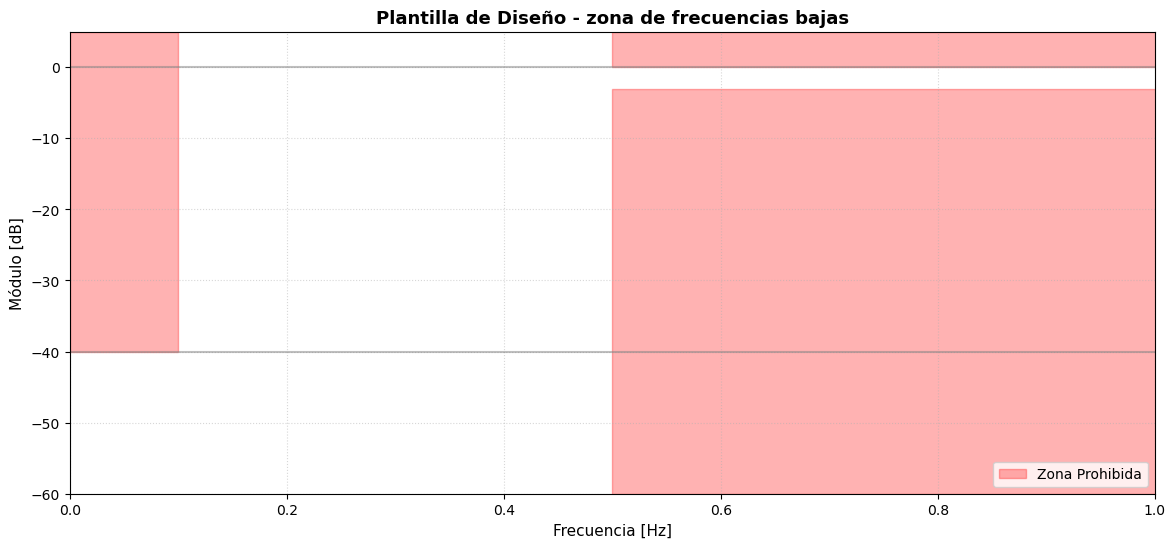

In [4]:
plt.figure(figsize=(14, 6))
limites_plantilla() # Llamo a la funcion para establecer los limites de la plantilla
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('Módulo [dB]', fontsize=11)
plt.title('Plantilla de Diseño', fontsize=13, fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))
limites_plantilla() # Llamo a la funcion para establecer los limites de la plantilla
plt.xlim(0, 1)
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('Módulo [dB]', fontsize=11)
plt.title('Plantilla de Diseño - zona de frecuencias bajas', fontsize=13, fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

# Filtros IIR


## Diseño de los filtros IIR

Se decidió comenzar por la creacion de filtros del tipo IIR. 

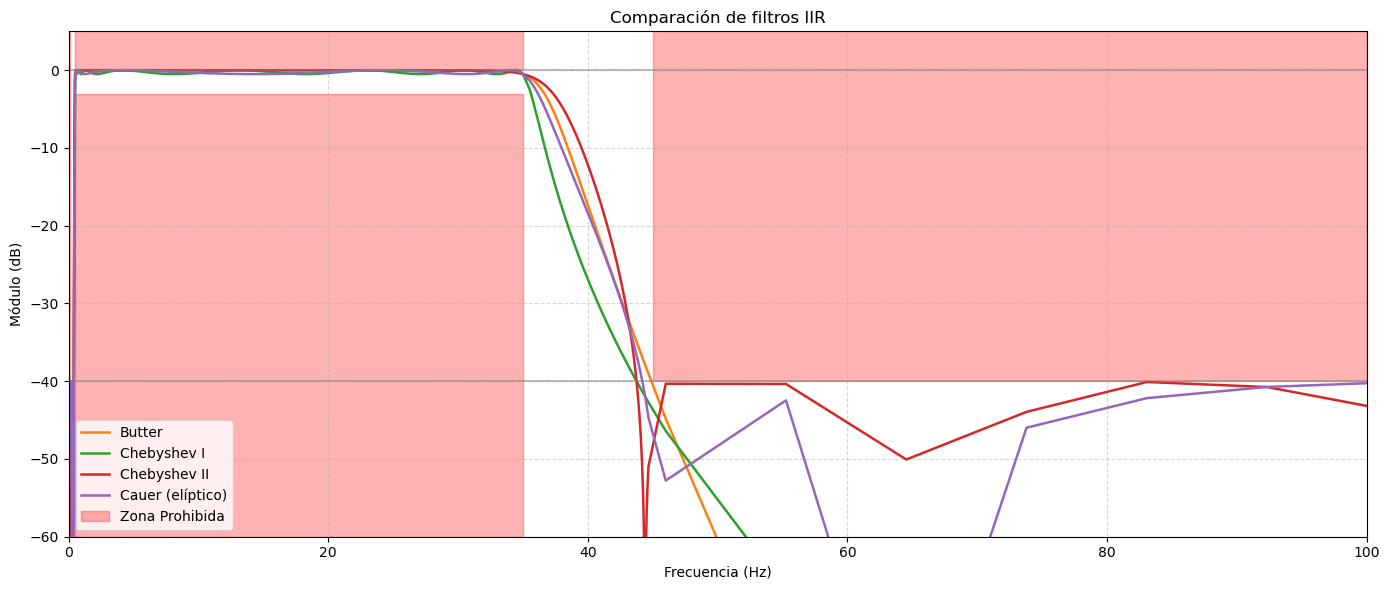

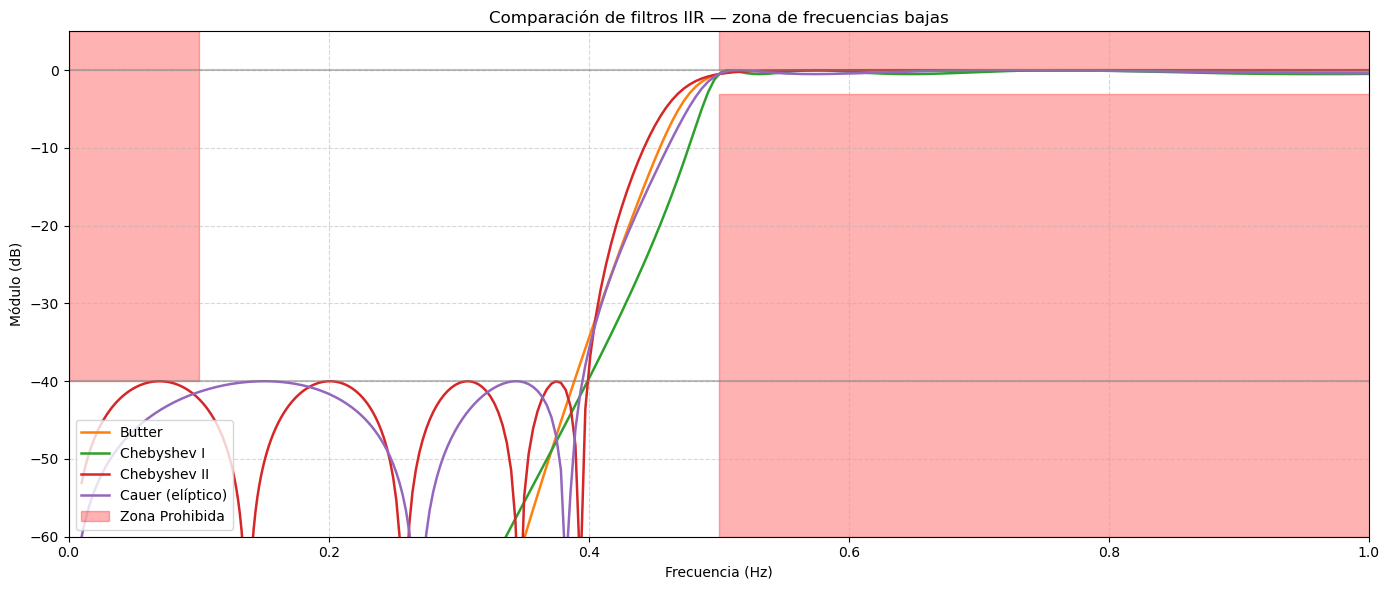

In [6]:
fs = 1000 # fs_ecg 

nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = 0.1
wp1 = 0.5
wp2 = 35
ws2 = 45

wp_iir = [wp1, wp2]
ws_iir = [ws1, ws2]

sos_but = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='butter', output='sos', fs=fs)
sos_chb1 = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='cheby1', output='sos', fs=fs)
sos_chb2 = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='cheby2', output='sos', fs=fs)
sos_cau = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='cauer', output='sos', fs=fs)

# Eje de frecuencias personalizado

ww = np.concatenate([np.logspace(start=-2,stop = 0.1, num = 500),
                     np.linspace(start = 1.26,stop = 35, num = 200),
                     np.logspace(start=1.55,stop = 1.65, num = 300),
                     np.linspace(start = 46,stop = fs//2, num = 50)])

filtros = [
    (sos_but,  'Butter',           'C1', '-'),
    (sos_chb1, 'Chebyshev I',      'C2', '-'),
    (sos_chb2, 'Chebyshev II',     'C3', '-'),
    (sos_cau,  'Cauer (elíptico)', 'C4', '-'),
]

eps = 1e-10  # evita log10(0)

plt.figure(figsize=(14, 6))

for sos, label, color, ls in filtros:
    omega, H = sig.freqz_sos(sos, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()

plt.title('Comparación de filtros IIR')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))

for sos, label, color, ls in filtros:
    omega, H = sig.freqz_sos(sos, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()
plt.xlim(0, 1)

plt.title('Comparación de filtros IIR — zona de frecuencias bajas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Como se puede observar todos cumplen con las especificaciones de la plantilla, algunos mejor que otros, siendo butter y cheby 1 los mejores.

## Implementación de filtros IIR

Veamos ahora como se verian los filtros IIR aplicados a la señal del ECG

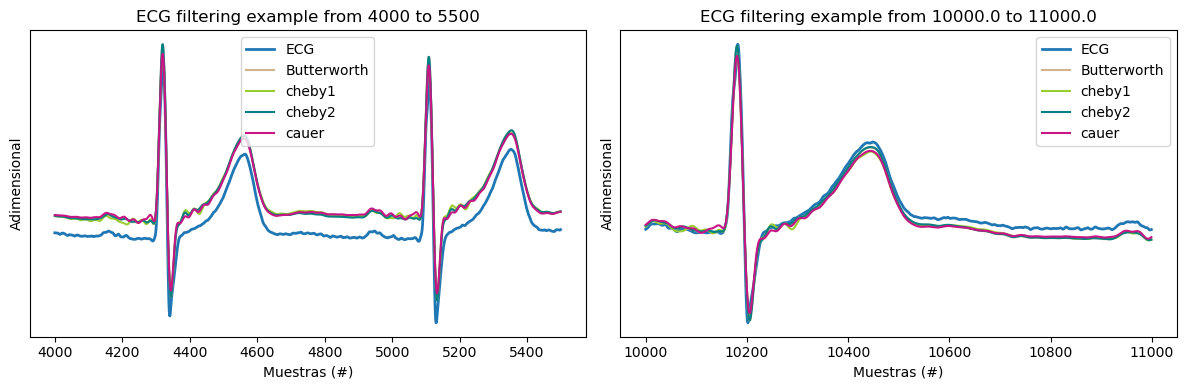

In [7]:
# Aplicamos el filtro 

ecg_but = sig.sosfiltfilt(sos_but, ecg_one_lead)
ecg_chb1 = sig.sosfiltfilt(sos_chb1, ecg_one_lead)
ecg_chb2 = sig.sosfiltfilt(sos_chb2, ecg_one_lead)
ecg_cau = sig.sosfiltfilt(sos_cau, ecg_one_lead)

# Regiones de interés sin ruido  
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_but[zoom_region], label='Butterworth', color='tan')
    ax.plot(zoom_region, ecg_chb1[zoom_region], label='cheby1', color='yellowgreen')
    ax.plot(zoom_region, ecg_chb2[zoom_region], label='cheby2', color='teal')
    ax.plot(zoom_region, ecg_cau[zoom_region], label='cauer', color='mediumvioletred')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()
 

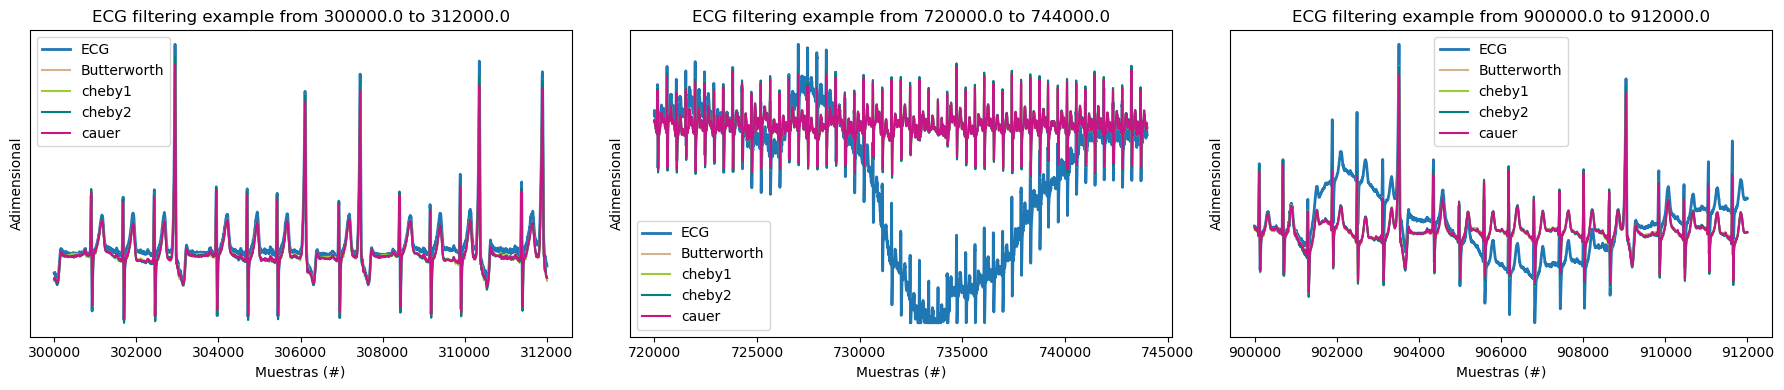

In [8]:
# Regiones de interés con ruido  
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_but[zoom_region], label='Butterworth', color='tan')
    ax.plot(zoom_region, ecg_chb1[zoom_region], label='cheby1', color='yellowgreen')
    ax.plot(zoom_region, ecg_chb2[zoom_region], label='cheby2', color='teal')
    ax.plot(zoom_region, ecg_cau[zoom_region], label='cauer', color='mediumvioletred')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

Como puede observarse blah blah

# Filtros FIR

## Metodo de ventanas

Para la implementacion de este metodo se hizo uso de la funcion firwin de scipy. 

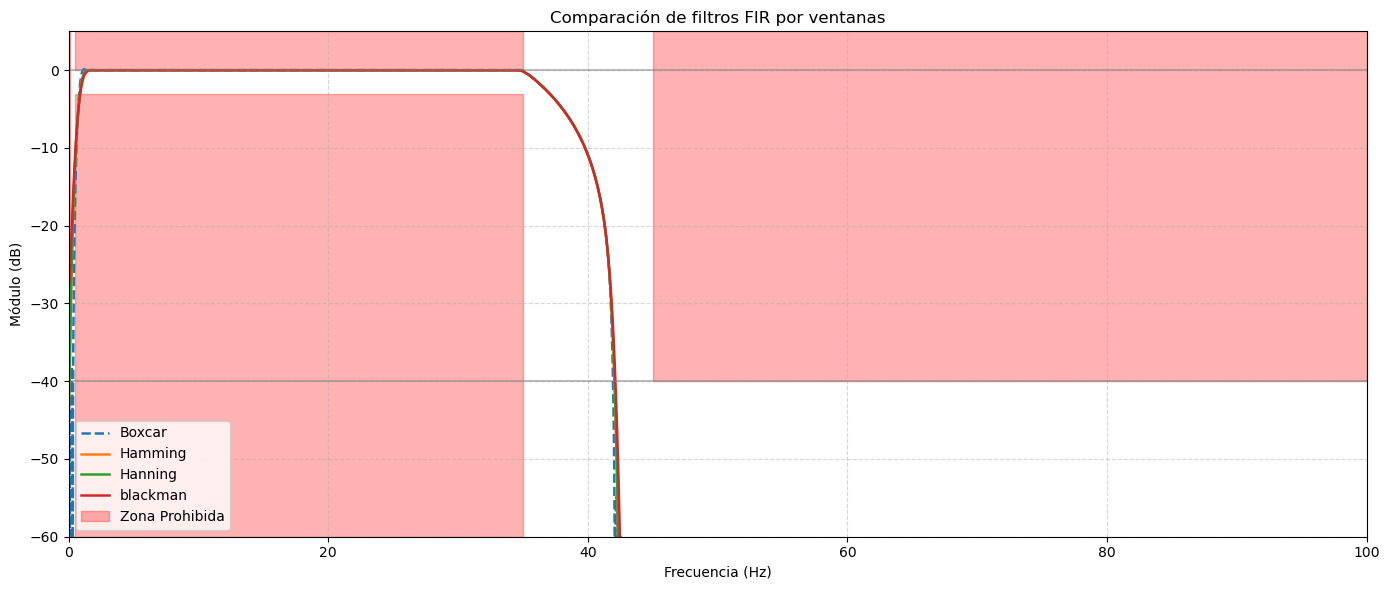

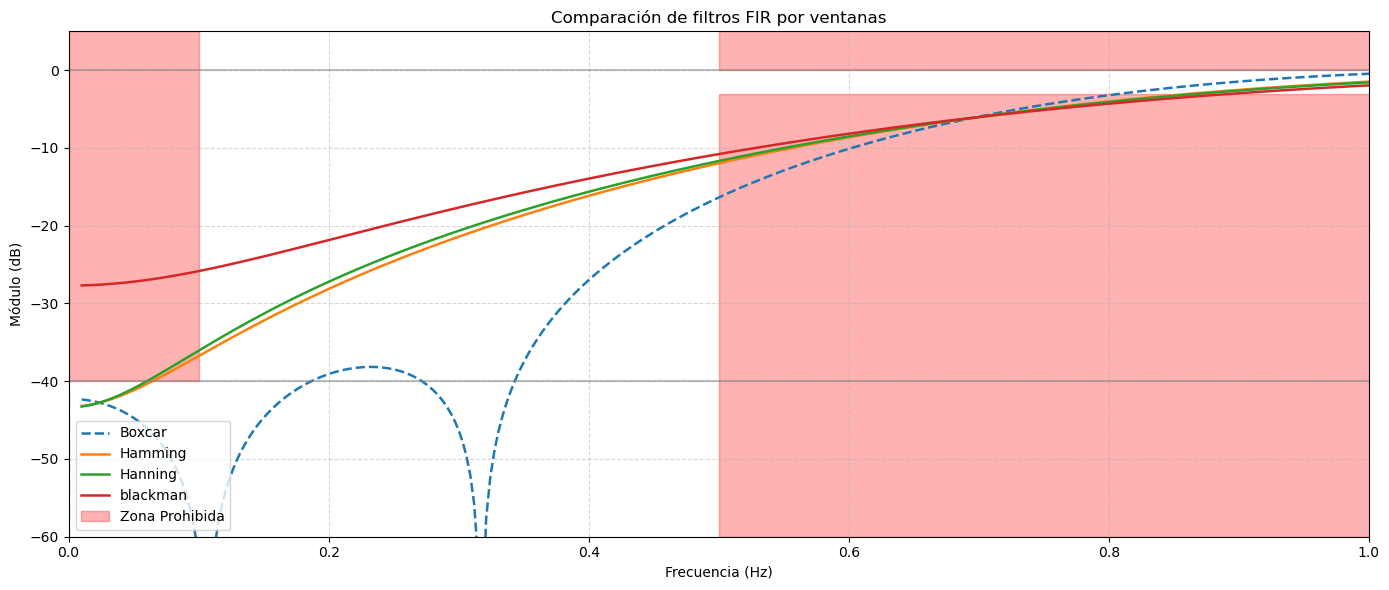

In [9]:
fs = 1000 # fs_ecg 
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = 0.4
wp1 = 1
wp2 = 35
ws2 = 42

frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ])
gains_db = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 3001
demora = (numtaps - 1)//2 

gain = np.array([0, 0, 1, 1, 0, 0])

b_win_box = sig.firwin2(numtaps, frecs, gain, nfreqs = 2**14, window='boxcar', fs=fs)
b_win_ham = sig.firwin2(numtaps, frecs, gain, nfreqs=2**14, window='hamming', fs=fs)
b_win_han = sig.firwin2(numtaps, frecs, gain, nfreqs=2**14, window='hann', fs=fs)
b_win_bla = sig.firwin2(numtaps, frecs, gain, nfreqs=2**14, window='blackman', fs=fs)

ww = np.concatenate([np.logspace(start=-2,stop = 0.1, num = 500),
                np.linspace(start = 1.26,stop = 35, num = 200),
                np.logspace(start=1.55,stop = 1.65, num = 300),
                np.linspace(start = 46,stop = fs//2, num = 50)])

filtros = [
    (b_win_box, 'Boxcar', 'C0', '--'),
    (b_win_ham,  'Hamming', 'C1', '-'),
    (b_win_han, 'Hanning', 'C2', '-'),
    (b_win_bla, 'blackman', 'C3', '-'),
]

eps = 1e-10 

plt.figure(figsize=(14, 6))

for b_win, label, color, ls in filtros:
    omega, H = sig.freqz(b_win, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()

plt.title('Comparación de filtros FIR por ventanas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))

for b_win, label, color, ls in filtros:
    omega, H = sig.freqz(b_win, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()
plt.xlim(0, 1)

plt.title('Comparación de filtros FIR por ventanas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Como se puede observar se cambiaron los valores de ws1, wp1 y wp2. Esto se hizo con la idea de conseguir una mejor adapcion de los filtros a la plantilla, para evitar trabajar con ordenes demasiado grandes. Ademas el wp2 = 40 sirve como "margen de error", algo que se trato de implementar en clase, con la idea de evitar situacion limite.

Si bien los resultados no los mejores, blackman es por lejos el peor de todos.

## Implementacion de filtros FIR por metodo de ventanas

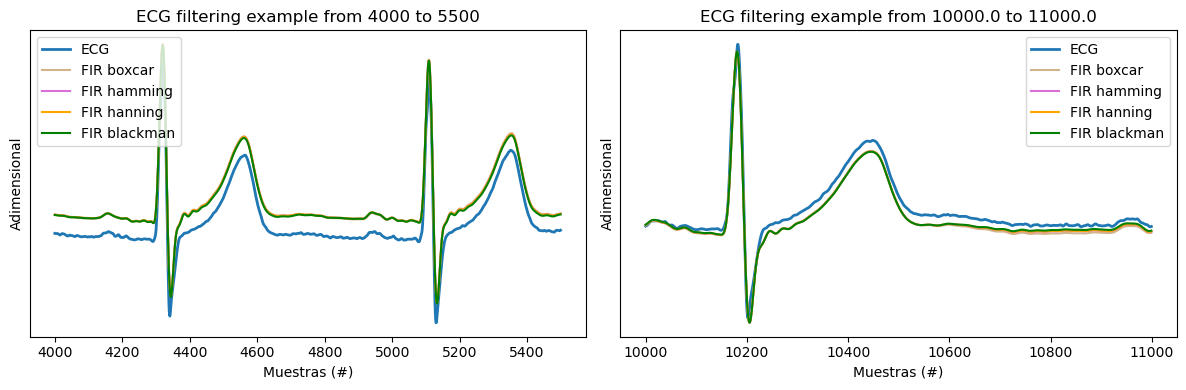

In [23]:
ecg_f_win_box = sig.lfilter(b_win_box, 1, ecg_one_lead)
ecg_f_win_ham = sig.lfilter(b_win_ham, 1, ecg_one_lead)
ecg_f_win_han = sig.lfilter(b_win_han, 1, ecg_one_lead)
ecg_f_win_bla = sig.lfilter(b_win_bla, 1, ecg_one_lead)

# Regiones de interés sin ruido  
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_f_win_box[zoom_region + demora], label='FIR boxcar', color='tan')
    ax.plot(zoom_region, ecg_f_win_ham[zoom_region + demora], label='FIR hamming', color='orchid')
    ax.plot(zoom_region, ecg_f_win_han[zoom_region + demora], label='FIR hanning', color='orange')
    ax.plot(zoom_region, ecg_f_win_bla[zoom_region + demora], label='FIR blackman', color='green')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()


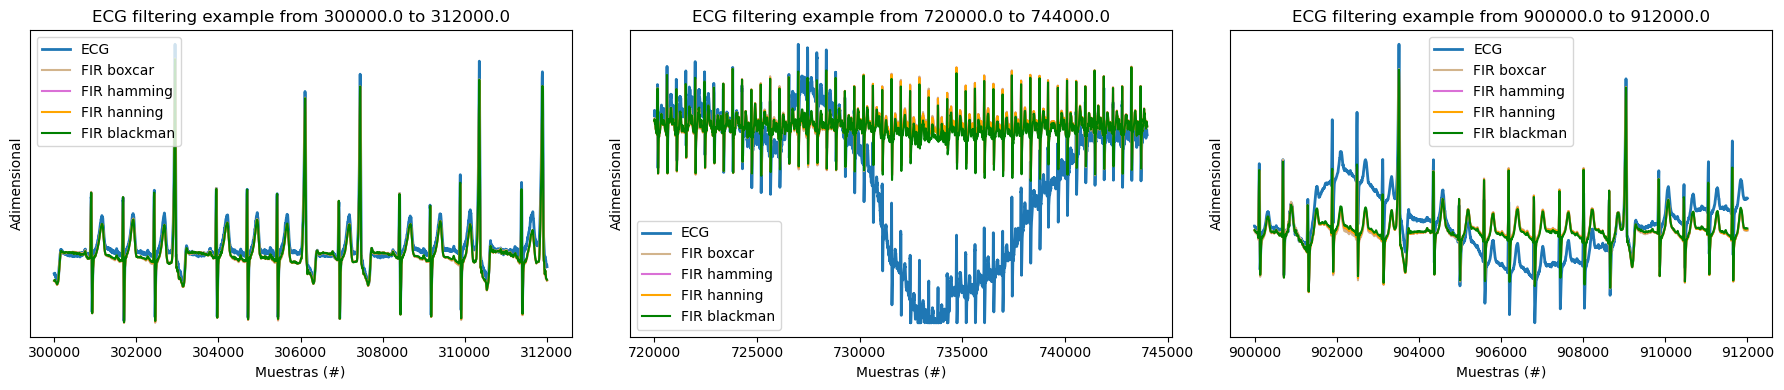

In [22]:
# Regiones de interés con ruido  
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )

fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_f_win_box[zoom_region + demora], label='FIR boxcar', color='tan')
    ax.plot(zoom_region, ecg_f_win_ham[zoom_region + demora], label='FIR hamming', color='orchid')
    ax.plot(zoom_region, ecg_f_win_han[zoom_region + demora], label='FIR hanning', color='orange')
    ax.plot(zoom_region, ecg_f_win_bla[zoom_region + demora], label='FIR blackman', color='green')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

Se ve que blah blah

## Metodo de Cuadrados Mínimos y metodo de Parks-Mc Clellan-Remez.

Para esta seccion se tomo en cuanta la funcion firls de scipy para el metdo de cuadrados minimos y remez para el de parks- Mc Clellan


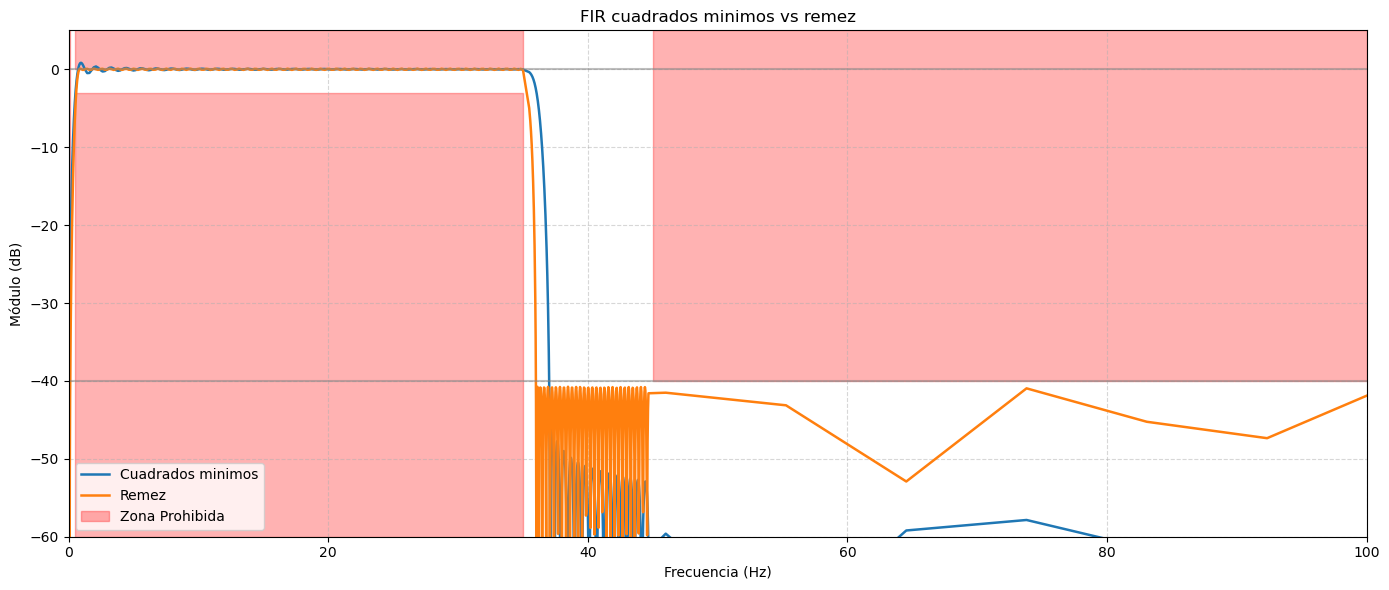

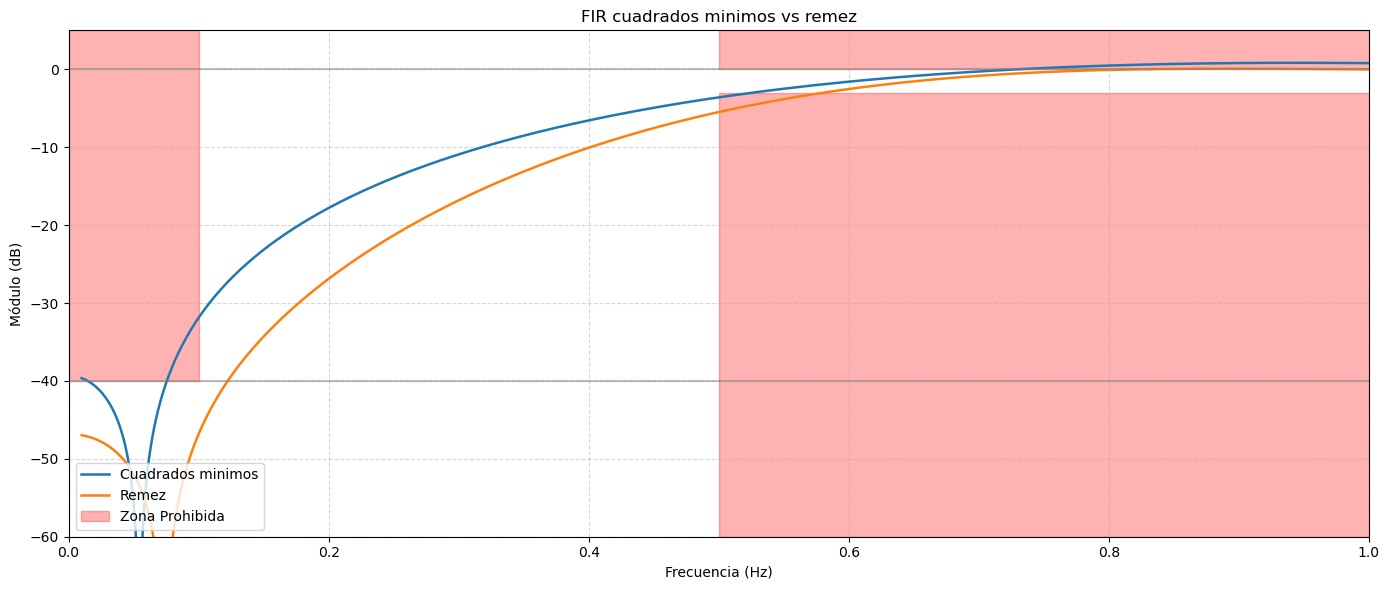

In [15]:

fs = 1000 # fs_ecg 
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB

# Cuadrados Mínimos

ws1 = 0.2
wp1 = 0.5
wp2 = 35
ws2 = 37

frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ])
gains_db = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])

desired = np.array([0, 0, 1, 1, 0, 0])

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 1701
weight = np.array([2,1,1])

h_firls = sig.firls(numtaps=numtaps, bands=frecs, desired=desired, weight=weight, fs=fs)

ww = np.concat([np.logspace(start=-2,stop = 0.1, num = 500),
                np.linspace(start = 1.26,stop = 35, num = 200),
                np.logspace(start=1.55,stop = 1.65, num = 300),
                np.linspace(start = 46,stop = fs//2, num = 50)])

omega_firls, H_firls = sig.freqz(h_firls, worN=ww, fs=fs)

# Parks-Mc Clellan-Remez

ws1_rm = 0.1
wp1_rm  = 0.8
wp2_rm  = 35
ws2_rm  = 36

frecs_rm  = np.array([0.0,         ws1_rm ,         wp1_rm ,     wp2_rm ,     ws2_rm ,         nyq_frec   ])

numtaps_remez = 3200
desired_remez = np.array([0,1,0])
weight_remez = np.array([2,1,1])

h_remez = sig.remez(numtaps = numtaps_remez, bands = frecs_rm , desired = desired_remez, weight = weight_remez, fs = fs)  

omega_remez, H_remez = sig.freqz(h_remez, worN=ww, fs=fs)

eps = 1e-10

plt.figure(figsize=(14, 6))

plt.plot(omega_firls, 20 * np.log10(np.abs(H_firls) + eps), label='Cuadrados minimos', color='C0', linewidth=1.8)
plt.plot(omega_remez, 20 * np.log10(np.abs(H_remez) + eps), label='Remez', color='C1', linewidth=1.8)

limites_plantilla()
plt.title('FIR cuadrados minimos vs remez')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))

plt.plot(omega_firls, 20 * np.log10(np.abs(H_firls) + eps), label='Cuadrados minimos', color='C0', linewidth=1.8)
plt.plot(omega_remez, 20 * np.log10(np.abs(H_remez) + eps), label='Remez', color='C1', linewidth=1.8)

limites_plantilla()
plt.xlim(0, 1)

plt.title('FIR cuadrados minimos vs remez')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


Para estos casos tambien fue necesario modificar los valores de ws1,ws2 y wp2 con el fin de adaptar mejor el filtro a la plantilla usando el menor orden posible.

## Implementacion de filtros FIR por cuadrados minimos y remez


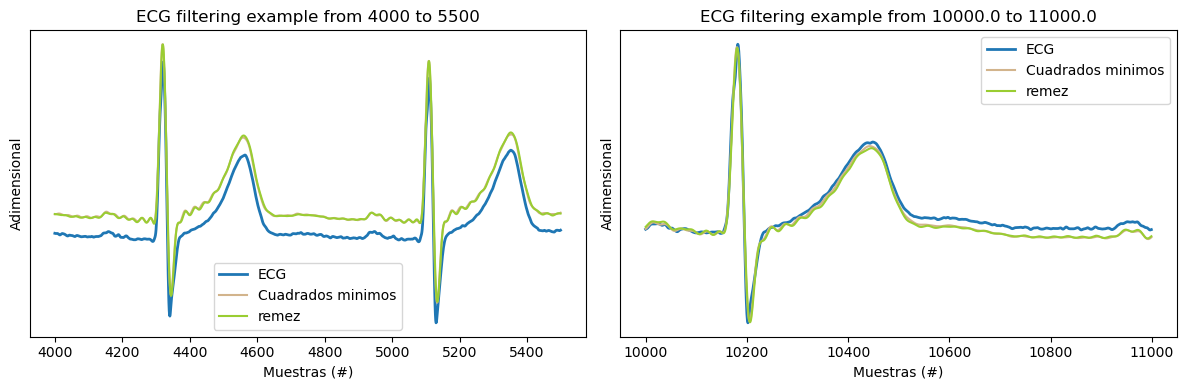

In [21]:
ecg_firls = sig.lfilter(h_firls, 1, ecg_one_lead)
ecg_remez = sig.lfilter(h_remez, 1, ecg_one_lead)

demora_firls = (numtaps - 1)//2 
demora_remez = (numtaps_remez - 1)//2 

# Regiones de interés sin ruido  
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_firls[zoom_region + demora_firls], label='Cuadrados minimos', color='tan')
    ax.plot(zoom_region, ecg_remez[zoom_region + demora_remez], label='remez', color='yellowgreen')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

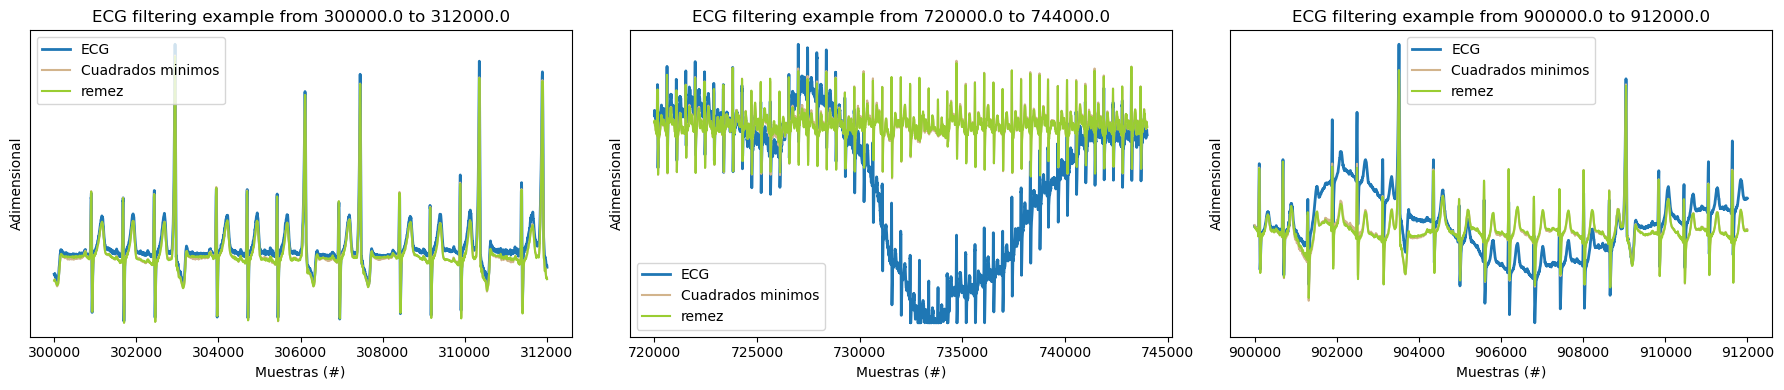

In [20]:
# Regiones de interés con ruido  
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )

fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_firls[zoom_region + demora_firls], label='Cuadrados minimos', color='tan')
    ax.plot(zoom_region, ecg_remez[zoom_region + demora_remez], label='remez', color='yellowgreen')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

se puede ver blah blah

# conclusiones

Como se pudo observar, a lo largo de este trabajo se crearon diversos tipos de filtros que luego fueron aplizados a la señal ECG. blah blah